<a href="https://colab.research.google.com/github/eniompw/mnist-mlp-from-scratch/blob/main/np_mlp_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

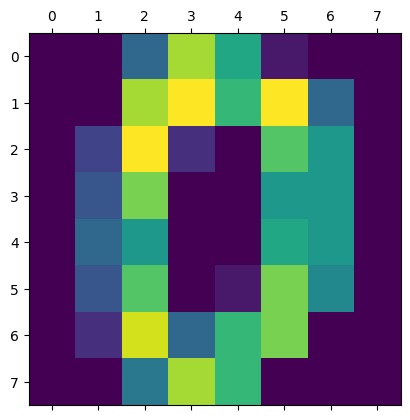

In [2]:
# Load digits dataset and visualize first sample
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
plt.matshow(digits.images[0])

In [3]:
# Print the label (digit) of the first sample
print(digits.target[0])

0


In [ ]:
from sklearn.datasets import load_digits
import numpy as np

# One forward pass: input -> ReLU hidden layer -> softmax output.
def forward(x_in):
    layer1 = np.maximum(0, x_in @ W1 + b1)  # ReLU hidden layer
    probs = softmax(layer1 @ W2 + b2)  # class probabilities
    return layer1, probs

# Softmax across classes for each sample.
def softmax(x):
    e_x = np.exp(x - x.max(axis=1, keepdims=True))  # numerically stable exp
    return e_x / e_x.sum(axis=1, keepdims=True)

# Load and preprocess data.
x, y = load_digits(return_X_y=True)  # 1797 samples, 64 features
x_mean = x.mean()
x_std = x.std()
x = (x - x_mean) / x_std  # standardize each input feature (pixel)
targets = np.eye(10)[y]  # one-hot labels, shape: (1797, 10)

# Initialize network: 64 -> 32 -> 10
np.random.seed(42)
W1, b1 = np.random.randn(64, 32) * 0.1, np.zeros((1, 32))  # hidden layer
W2, b2 = np.random.randn(32, 10) * 0.1, np.zeros((1, 10))  # output layer
lr = 0.1

# Training loop (full-batch gradient descent).
for epoch in range(1000):
    # Forward pass.
    layer1, probs = forward(x)

    # Backward pass: gradient of cross-entropy with softmax.
    output_error = (probs - targets) / len(x)
    layer1_error = (output_error @ W2.T) * (layer1 > 0)  # dL/dZ1 (ReLU gate)

    # Parameter update.
    W2 -= lr * layer1.T @ output_error
    b2 -= lr * output_error.sum(0, keepdims=True)
    W1 -= lr * x.T @ layer1_error
    b1 -= lr * layer1_error.sum(0, keepdims=True)

    if epoch % 100 == 0:
        acc = np.mean(probs.argmax(1) == y)
        print(f"Epoch {epoch:4d} | Acc: {acc:.0%}")


Epoch    0 | Acc: 10%
Epoch  100 | Acc: 93%
Epoch  200 | Acc: 96%
Epoch  300 | Acc: 97%
Epoch  400 | Acc: 98%
Epoch  500 | Acc: 99%
Epoch  600 | Acc: 99%
Epoch  700 | Acc: 99%
Epoch  800 | Acc: 99%
Epoch  900 | Acc: 99%


In [ ]:
# Predict the first digit sample.
x = digits.images[0].reshape(1, -1)  # shape: (1, 64)
x = (x - x_mean) / x_std  # standardize each input feature (pixel)
_, pred = forward(x)               # class probabilities
print(pred.argmax())                    # predicted label


0
